# Isaac Sim Jupyter Notebook Tutorial

This notebook will demonstrate step by step how to load the IAI apartment and a robot into the simulation environment.
 
> Select the jupyter kernel `Isaac Sim Python 3.11` if you are running in VScode.
>
> "Control + Enter" to execute the selected code cell. 

<!-- <button data-commandlinker-command="notebook:restart" class="jupyter-button">Force Stop</button> -->

## Start the GPU monitor and virtual desktop

Make sure the GPU has at least 3000M free memory.

If the virtual desktop does not pop up, manually click the "Open Desktop in new Tab".

In [1]:
from IPython import get_ipython
in_notebook = get_ipython().__class__.__name__ == "ZMQInteractiveShell"

from utils import *
# Extract precompiled cache
run_script(CACHE_EXTRACT_CMD)

# only runs in Jupyter Notebook
if in_notebook:
    from gpu_monitor import GPUMonitor
    # Monitor GPU usage
    gpu_monitor = GPUMonitor()
    # Open Desktop in sidecar
    display_desktop()

HTML(value='')

HTML(value='<a href="https://jupyter.dev.intel4coro.de//user/yxzhan-isaacsim-template-wzl58j2n/desktop"  class…

## Start SimulationApp

The application window is frozen and non-interactive, which is normal.

<div style="color:red">This will take some time, so give it a minute and wait for it to say <b>"SimulationApp Ready!"</b> before you go to next step.</div>

In [1]:
from isaacsim import SimulationApp
from IPython.display import clear_output
import sys
import builtins

in_notebook = get_ipython().__class__.__name__ == "ZMQInteractiveShell"
original_stdout = sys.stdout
original_stderr = sys.stderr

simulation_app = SimulationApp({
    "headless": False,
    # "hide_ui": True,
    "width": 1280,
    "height": 960,
    "renderer": "RaytracedLighting",
    "display_options": 3286,  # Setsimulation_app.update() display options to show default grid
})

# Fix the issue where notebook output is being hijacked by Isaac Sim.
sys.stdout = original_stdout
sys.stderr = original_stderr
clear_output(wait=True)
print('SimulationApp Ready!')

SimulationApp Ready!


## Create a simulation environment

Setting physics to update at 200 Hz, rendering at 25 Hz, and using meters as the unit scale.

In [2]:
from isaacsim.core.api import World
from isaacsim.core.utils.prims import define_prim
from isaacsim.storage.native import get_assets_root_path

from isaacsim.core.utils.extensions import enable_extension
enable_extension("omni.physx.supportui")
enable_extension("isaacsim.ros2.bridge")

my_world = World(stage_units_in_meters=1.0,
                 physics_dt=1 / 200,
                 rendering_dt=8 / 200)
my_world.reset()

assets_root_path = get_assets_root_path()
prim = define_prim("/World/Ground", "Xform")
asset_path = assets_root_path + "/Isaac/Environments/Grid/default_environment.usd"
prim.GetReferences().AddReference(asset_path)

set 0: [SimpleListItem]: 1.0: 1.0, <omni.ui._ui.SimpleFloatModel object at 0x79c4610c03f0>, [1.0, 0.6000000238418579, 0.0, 1.0]
set 1: [SimpleListItem]: 0.6: 0.6, <omni.ui._ui.SimpleFloatModel object at 0x79c4473f9c30>, [1.0, 0.6000000238418579, 0.0, 1.0]
set 2: [SimpleListItem]: 0.0: 0.0, <omni.ui._ui.SimpleFloatModel object at 0x79c4473e2570>, [1.0, 0.6000000238418579, 0.0, 1.0]
set 3: [SimpleListItem]: 1.0: 1.0, <omni.ui._ui.SimpleFloatModel object at 0x79c4473e15f0>, [1.0, 0.6000000238418579, 0.0, 1.0]


True

[8.824s] Simulation App Startup Complete
[112.831s] [ext: omni.debugdraw-0.1.4] startup
[112.838s] [ext: omni.kit.widget.layers-1.8.6] startup
[112.900s] [ext: omni.usdphysics.ui-107.3.26] startup
[112.928s] [ext: omni.physx.commands-107.3.26] startup
[112.932s] [ext: omni.physx.ui-107.3.26] startup
[113.128s] [ext: omni.physx.supportui-107.3.26] startup
[113.194s] [ext: isaacsim.ros2.bridge-4.12.4] startup
[113.237s] Attempting to load system rclpy
[113.237s] Could not import system rclpy: No module named 'rclpy'
[113.237s] Attempting to load internal rclpy for ROS Distro: jazzy
[113.256s] rclpy loaded


## Refresh View

Create a helper function to step the simulation world and update view. For the later code cells, wait for the progress bar to complete before proceeding to the next step.

In [3]:
from tqdm import tqdm

def refresh_view(steps=10, desc="World Stepping"):
    bar_format = "{l_bar}{bar}| {n_fmt}/{total_fmt} steps] {elapsed_s:.2f}s"
    for i in tqdm(range(steps), desc=desc, ncols=60, bar_format=bar_format, file=sys.stdout):
        my_world.step(render=True)

refresh_view()

World Stepping: 100%|███████████████████| 10/10 steps] 2.37s


## Spawn Apartment USD to the world

Asset Source:
https://github.com/Multiverse-Framework/Multiverse-Tutorials/tree/main/resources/apartmentICRA_full/usda

In [4]:
import numpy as np
from isaacsim.core.utils.prims import create_prim
from isaacsim.core.utils import viewports

env_usd_path = "/mnt/dev-tools/usd/apartment/apartmentICRA.usda"

create_prim(
    usd_path=env_usd_path,
    prim_path=f"/World/Apartment",
    position=np.array([-6, 5, 0.0701]),
    # orientation=np.array([0, 0, 0, 1])
)

viewports.set_camera_view(eye=np.array([-15, 0, 1.5]), 
                          target=np.array([0, 0, 0.5]))

refresh_view(steps=30, desc="Spawn Apartment")

Spawn Apartment: 100%|██████████████████| 30/30 steps] 1.88s


## Add lights

In [5]:
from isaacsim.core.utils.prims import create_prim

for i in range(1,4):
    gap = 4
    create_prim(
        prim_path=f"/World/Ground/Light_{i}",
        prim_type="SphereLight",
        attributes={"inputs:intensity": 10000},
        position=(-gap * i, 0, 2)
    )
    refresh_view(steps=10, desc="Add Lights")

Add Lights: 100%|███████████████████████| 10/10 steps] 0.33s
Add Lights: 100%|███████████████████████| 10/10 steps] 0.33s
Add Lights: 100%|███████████████████████| 10/10 steps] 0.33s


## Move Viewport Camera

In [6]:
import numpy as np
from isaacsim.core.utils import viewports
from omni.kit.viewport.utility.camera_state import ViewportCameraState

def move_camera(position, target, steps=100, smooth=True):
    end_pos = np.array(position)
    end_target = np.array(target)

    if smooth:
        # get current camera state
        cam_state = ViewportCameraState()
        start_pos = np.asarray(cam_state.position_world, dtype=np.double)
        start_target = np.asarray(cam_state.target_world, dtype=np.double)
        offset_pos = (end_pos - start_pos) / steps
        offset_target = (end_target - start_target) / steps
        for i in tqdm(range(steps), desc="Move Camera", file=sys.stdout):
            viewports.set_camera_view(eye=start_pos + offset_pos * i, 
                                      target=start_target + offset_target * i )
            my_world.step(render=True)
    else:
        viewports.set_camera_view(eye=end_pos, target=end_target)
    
    refresh_view(steps=10)

move_camera(position=[-7, -2, 2], target=[-1, 1, 1], steps=50)

Move Camera: 100%|██████████| 50/50 [00:01<00:00, 28.03it/s]
World Stepping: 100%|███████████████████| 10/10 steps] 0.35s


## Spawn Robots

In [7]:
import os
import numpy as np
from isaacsim.core.utils.prims import create_prim

# IAI robots
robots = [
    "stretch",
    "pr2",
    "hsrb",
    "tiago_dual",
]

for i in range(len(robots)):
    robot = robots[i]
    create_prim(
        usd_path=f"{os.getcwd()}/../usd/{robot}/{robot}.usd",
        prim_path=f"/World/{robot}",
        position=np.array([-i * 3 - 1, 0, 0.05]),
        orientation=np.array([0, 0, 0, 1])
    )
    refresh_view(steps=30, desc=f"Spawn {robot}")

Spawn stretch: 100%|████████████████████| 30/30 steps] 1.13s
Spawn pr2: 100%|████████████████████████| 30/30 steps] 1.19s
2025-12-17T14:09:52Z [173,343ms] [Warning] [carb] Client gpu.foundation.plugin has acquired [gpu::unstable::IMemoryBudgetManagerFactory v0.1] 100 times. Consider accessing this interface with carb::getCachedInterface() (Performance warning)
2025-12-17T14:09:54Z [175,772ms] [Warning] [omni.fabric.plugin] getAttributeCount called on non-existent path /World/stretch/base_link/collisions/mesh_1
2025-12-17T14:09:54Z [175,772ms] [Warning] [omni.fabric.plugin] getTypes called on non-existent path /World/stretch/base_link/collisions/mesh_1
2025-12-17T14:09:57Z [178,056ms] [Warning] [omni.usd] Warning: in _ReportErrors at line 3172 of /builds/omniverse/usd-ci/USD/pxr/usd/usd/stage.cpp -- In </World/hsrb/hsrb/visuals>: Unresolved reference prim path @/mnt/dev-tools/isaacsim-template/usd/hsrb/configuration/hsrb_physics.usd@</visuals/hsrb> introduced by @/mnt/dev-tools/isaacsim

## Delete Robots

In [8]:
from isaacsim.core.utils.prims import delete_prim

# for i in range(len(robots)):
#     robot = robots[i]
#     delete_prim(f"/World/{robot}")
#     refresh_view(steps=10, desc=f"Delete {robot}")

## Create Robots Articulations

In [9]:
from isaacsim.core.prims import Articulation

robot_arts = {}

for robot in robots:
    robot_arts[robot] = Articulation(prim_paths_expr=f"/World/{robot}", name=f"my_{robot}")

## Get Joint Info

In [10]:
import pandas as pd

def get_joint_info(robot_art):
    joint_names = robot_art.dof_names
    joint_num = robot_art.num_dof
    joint_types = robot_art.get_dof_types()
    joint_limits = robot_art.get_dof_limits()[0]
    joint_states = robot_art.get_joint_positions()[0]
    
    df = pd.DataFrame({
        "Joint Name": joint_names,
        "Current Position": joint_states,
        "Lower Limit": [lim[0] for lim in joint_limits],
        "Upper Limit": [lim[1] for lim in joint_limits],
        "Type": joint_types,
    })
    
    unlimited = 3e38
    df["Lower Limit"] = df["Lower Limit"].mask(df["Lower Limit"] < -unlimited, -np.inf)
    df["Upper Limit"] = df["Upper Limit"].mask(df["Upper Limit"] > unlimited, np.inf)
    return df

if in_notebook:
    display(get_joint_info(robot_arts["stretch"]).style.format({
        "Lower Limit": "{:.8f}",
        "Upper Limit": "{:.8f}",
        "Current Position": "{:.8f}"
    }))

,Joint Name,Current Position,Lower Limit,Upper Limit,Type
0,joint_head_pan,0.00000601,-3.89999986,1.49999988,DofType.Rotation
1,joint_left_wheel,-0.00447560,-inf,inf,DofType.Rotation
2,joint_lift,0.00000000,0.00000000,1.10000002,DofType.Translation
3,joint_right_wheel,-0.00251485,-inf,inf,DofType.Rotation
4,joint_head_tilt,-0.00012732,-1.52999985,0.78999996,DofType.Rotation
5,joint_arm_l3,0.00006165,0.00000000,0.13000000,DofType.Translation
6,joint_arm_l2,0.00005929,0.00000000,0.13000000,DofType.Translation
7,joint_arm_l1,0.00006579,0.00000000,0.13000000,DofType.Translation
8,joint_arm_l0,0.00006149,0.00000000,0.13000000,DofType.Translation
9,joint_wrist_yaw,0.00000124,-1.74999988,3.99999976,DofType.Rotation


## Low Level Joint Control

In [11]:
def set_joint_pos(
    robot_art,
    joint_pos: dict = None,
    teleport: bool = False,
    max_steps: int = 100,
    threshold: float = 0.01
) -> dict:
    """
    Set target joint positions for a robot Articulation.

    Args:
        robot_art: Isaac Sim ArticulationView or similar class
        joint_pos (dict): {joint_name: target_position}
        teleport (bool): If True, instantly set joint positions
        max_steps (int): Maximum simulation steps to wait
        threshold (float): Required closeness between current and target joint positions

    Returns:
        dict: {
            "success": bool,
            "steps_used": int | None,
            "report": DataFrame | None,
            "message": str
        }
    """
    if joint_pos is None:
        joint_pos = {}

    joint_limits = robot_art.get_dof_limits()[0]
    joint_names = np.array(robot_art.dof_names)
    target_joint_pos = robot_art.get_joint_positions()[0].copy()

    # --- Apply limits and fill in target positions ---
    for name, value in joint_pos.items():
        idx = robot_art.get_dof_index(name)
        lower, upper = joint_limits[idx]
        clamped = np.clip(value, lower, upper)
        target_joint_pos[idx] = clamped

    # --- Instant teleport mode ---
    if teleport:
        robot_art.set_joint_positions([target_joint_pos])
        refresh_view(steps=10, desc="Teleport joints to target position")
        return {
            "success": True,
            "steps_used": 0,
            "report": None,
            "message": "Joints teleported successfully."
        }

    # --- Motion mode: send targets ---
    robot_art.set_joint_position_targets([target_joint_pos])
    if max_steps == 0:
        return None
    
    check_indices = np.array([robot_art.get_dof_index(name) for name in joint_pos])

    reached = False
    last_joint_pos = None

    # for step in tqdm(range(max_steps), file=sys.stdout):
        # my_world.step(render=True)
    eps_size = 10
    steps = max_steps
    while steps > 0:
        refresh_view(steps=10, desc=f"{steps} steps left...")
        steps -= 10
        last_joint_pos = robot_art.get_joint_positions()[0]

        abs_diff = np.abs(last_joint_pos[check_indices] - target_joint_pos[check_indices])
        reached = (abs_diff <= threshold).all()

        if reached:
            return {
                "success": True,
                "steps_used": max_steps - steps,
                "report": None,
                "message": "Joints reached target positions."
            }

    # --- Not reached: prepare failure report ---
    diff_mask = abs_diff >= threshold
    diff_indices = check_indices[diff_mask]

    report = pd.DataFrame({
        "Joint Name": joint_names[diff_indices],
        "Current Position": last_joint_pos[diff_indices],
        "Target Position": target_joint_pos[diff_indices],
        "Abs Diff": abs_diff[diff_mask]
    })

    return {
        "success": False,
        "steps_used": max_steps,
        "report": report,
        "message": "Failed to reach target positions within step limit."
    }


## Reset Robot

In [12]:
def set_init_pose():
    my_world.reset()
    refresh_view()

    set_joint_pos(robot_arts["stretch"], {
        "joint_lift": 0.7,
        "joint_head_tilt": -0.3,
        # "joint_head_pan": -3
    }, max_steps=0)

    set_joint_pos(robot_arts["pr2"], {
        # "torso_lift_joint": 0.3,
        # right_side
        "r_gripper_l_finger_joint": 0.5,
        "r_shoulder_pan_joint": -1.7125,
        "r_shoulder_lift_joint": -0.25672,
        "r_upper_arm_roll_joint": -1.46335,
        "r_elbow_flex_joint": -2.12,
        "r_forearm_roll_joint": 1.76632,
        "r_wrist_flex_joint": 1.76632,
        "r_forearm_roll_joint": 1.76632,
        "r_wrist_flex_joint": -0.10001,
        "r_wrist_roll_joint": 0.05106,
        # left_side
        "l_gripper_l_finger_joint": 0.5,
        "l_shoulder_pan_joint": 1.7125,
        "l_shoulder_lift_joint": -0.25672,
        "l_upper_arm_roll_joint": 1.46335,
        "l_elbow_flex_joint": -2.12,
        "l_forearm_roll_joint": -1.76632,
        "l_wrist_flex_joint": 1.76632,
        "l_forearm_roll_joint": -1.76632,
        "l_wrist_flex_joint": -0.10001,
        "l_wrist_roll_joint": 0.05106,
    }, max_steps=0)
    
    refresh_view(steps=50)

set_init_pose()

World Stepping: 100%|███████████████████| 10/10 steps] 0.54s
World Stepping: 100%|███████████████████| 50/50 steps] 2.34s


## Test Joints and Base Move

In [17]:
def test_dof_joints(robot_art):
    for row in get_joint_info(robot_art)[:30].itertuples(index=True):
        joint_idx = row[0]
        init_pos = row[2]
        joint_name = row[1]
        lower = row[3]
        upper = row[4]
        if lower == -np.inf or upper == np.inf:
            continue
        print(joint_name)
        teleport = False
        max_steps = 20
        for val in [lower, upper, init_pos]:
            res = set_joint_pos(
                robot_art,
                {joint_name: val},
                teleport=teleport,
                max_steps=max_steps
            )
            if res is not None and not res["success"]:
                print(res["report"])

def test_base_move(robot_art, velocity=5):
    joint_names = robot_art.dof_names
    joint_num = robot_art.num_dof
    # find wheel joints
    wheel_indices = np.where(np.char.find(joint_names, "wheel") >= 0)[0]
    left_wheel_indices = np.where(
        (np.char.find(joint_names, "left_wheel") != -1) |
        (np.char.find(joint_names, "l_caster_l_wheel") != -1) |
        (np.char.find(joint_names, "l_caster_r_wheel") != -1)
    )[0]
    right_wheel_indices = np.where(
        (np.char.find(joint_names, "right_wheel") != -1) |
        (np.char.find(joint_names, "r_caster_l_wheel") != -1) |
        (np.char.find(joint_names, "r_caster_r_wheel") != -1)
    )[0]

    next_joint_vel = np.zeros(joint_num)
    next_joint_vel[wheel_indices] = velocity
    robot_art.set_joint_velocity_targets([next_joint_vel])
    refresh_view(steps=50, desc="Forward")

    next_joint_vel = np.zeros(joint_num)
    next_joint_vel[left_wheel_indices] = -velocity
    next_joint_vel[right_wheel_indices] = velocity
    robot_art.set_joint_velocity_targets([next_joint_vel])
    refresh_view(steps=100, desc="Turn Left")

    next_joint_vel = np.zeros(joint_num)
    next_joint_vel[wheel_indices] = -velocity
    robot_art.set_joint_velocity_targets([next_joint_vel])
    refresh_view(steps=50, desc="Backward")
    
    robot_art.set_joint_velocities([np.zeros(joint_num)])
    refresh_view(steps=10, desc="Stop")


# for robot in robots:
#     print(f"Testing {robot}")
#     test_base_move(robot_arts[robot])
#     test_dof_joints(robot_arts[robot])
# test_dof_joints(robot_arts["stretch"])
# test_base_move(robot_arts["stretch"], 3)
test_base_move(robot_arts["pr2"], 1)

Forward: 100%|██████████████████████████| 50/50 steps] 2.49s
Turn Left: 100%|██████████████████████| 100/100 steps] 4.91s
Backward: 100%|█████████████████████████| 50/50 steps] 2.41s
Stop: 100%|█████████████████████████████| 10/10 steps] 0.48s


## Spawn Kitchen Objects

In [14]:
import os
import random

# asset_dir = "/mnt/dev-tools/Multiverse/Multiverse-Assets/objects"
# asset_names = [name for name in os.listdir(asset_dir) 
#                     if os.path.isdir(os.path.join(asset_dir, name))]

asset_dir = "/mnt/dev-tools/usd/Collected_KichenRoom/Kitchen_Other"
asset_names = [os.path.splitext(f)[0] 
               for f in os.listdir(asset_dir) 
               if f.endswith(".usd")]

exclude_keys = ["Shelf", "Flower", "Hookrack", "Kitchen_Disk001"]
asset_names = [x for x in asset_names if not any(k in x for k in exclude_keys)]

num_sample = min(5, len(asset_names))
sampled = random.sample(asset_names, num_sample)
object_prims = []

table_loc = np.array([
    # [0.5, 0, 1], # Kitchen island
    [-2, -1.6, 1],  # table right
    # [-4, 1.5, 1],  # table left
])

for i in range(num_sample):
    asset = sampled[i]
    prim_path = f"/World/{asset}_{i}"
    center = table_loc[np.random.randint(len(table_loc))]
    x_random = 0.5
    y_random = 0.3
    x = random.uniform(center[0] - x_random, center[0] + x_random)
    y = random.uniform(center[1] - y_random, center[1] + y_random)
    z = center[2]
    create_prim(
        # usd_path=f"{asset_dir}/{asset}/{asset}.usda",
        usd_path=f"{asset_dir}/{asset}.usd",
        prim_path=prim_path,
        position=[x, y, z],
    )
    object_prims.append(prim_path)
    refresh_view(steps=20, desc=f"Spawn {asset}")

refresh_view(steps=50)

# Delete Kitchen Objects
# for prim in object_prims:
#     delete_prim(prim)
# refresh_view(steps=20, desc="Delete kitchen objects")

Spawn Kitchen_Box07: 100%|██████████████| 20/20 steps] 1.08s
Spawn Kitchen_bottle004: 100%|██████████| 20/20 steps] 0.82s
Spawn Kitchen_Bottle007: 100%|██████████| 20/20 steps] 0.81s
Spawn Kitchen_Bottle005: 100%|██████████| 20/20 steps] 0.81s
Spawn Kitchen_Orange002: 100%|██████████| 20/20 steps] 0.87s
World Stepping: 100%|███████████████████| 50/50 steps] 2.07s


## Add Camera Sensors

In [15]:
import omni
from pxr import Usd, UsdGeom
from isaacsim.sensors.camera import Camera
import isaacsim.core.utils.numpy.rotations as rot_utils

def create_cam(prim_path, focal_length=1.0, orientation=[0, 0, 0]):
    stage = omni.usd.get_context().get_stage()
    UsdGeom.Camera.Define(stage, prim_path)
    camera = Camera(
        prim_path=prim_path,
        frequency=30,
        resolution=(1280, 720),
        orientation=rot_utils.euler_angles_to_quats(np.array(orientation), degrees=True),
    )
    camera.initialize()
    camera.set_focal_length(focal_length)
    camera.set_clipping_range(near_distance=0.01, far_distance=20)
    return camera


head_cam_prim = "/World/stretch/link_head_tilt/camera_bottom_screw_frame/camera_link/camera_color_frame/camera_color_optical_frame"
gripper_cam_prim = "/World/stretch/link_wrist_roll/link_gripper_s3_body/gripper_camera_bottom_screw_frame/gripper_camera_link/gripper_camera_color_frame/gripper_camera_color_optical_frame"

stretch_head_cam = create_cam(head_cam_prim, focal_length=1.5, orientation=[-90, 0, 0])
stretch_gripper_cam = create_cam(gripper_cam_prim, orientation=[0, 0, 0])

refresh_view(steps=50)

World Stepping: 100%|███████████████████| 50/50 steps] 2.91s
2025-12-17T14:11:32Z [273,581ms] [Warning] [isaacsim.sensors.camera.camera] 'verticalAperture' (1.5290800094604493) and 'horizontalAperture' (2.0954999923706055) are inconsistent with the pixel resolution aspect ratio (1.7777777777777777). Setting 'verticalAperture' to 1.1787187457084656 to ensure square pixels.
2025-12-17T14:11:32Z [273,649ms] [Warning] [isaacsim.sensors.camera.camera] 'verticalAperture' (1.5290800094604493) and 'horizontalAperture' (2.0954999923706055) are inconsistent with the pixel resolution aspect ratio (1.7777777777777777). Setting 'verticalAperture' to 1.1787187457084656 to ensure square pixels.
2025-12-17T14:11:32Z [273,696ms] [Warning] [omni.fabric.plugin] USD->Fabric: Unhandled array type string[]
2025-12-17T14:11:32Z [273,701ms] [Warning] [usdrt.population.plugin] [UsdNoticeHandler] Unhandled attribute type VtArray<std::string> (prim attribute: omni:rtx:material:db:flattener:transmittance_color)
2

### Inspect Camera Data


0: 384x640 1 bottle, 1 dining table, 38.9ms
1: 384x640 1 chair, 2 dining tables, 1 tv, 38.9ms
Speed: 5.6ms preprocess, 38.9ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)


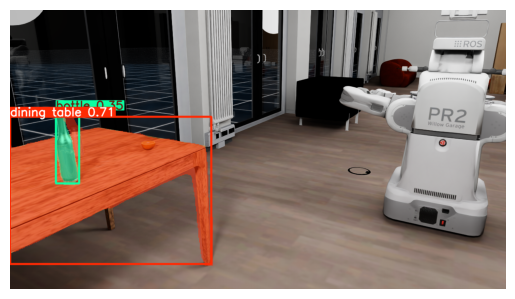

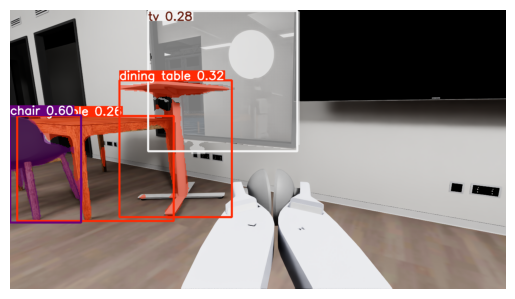

In [16]:
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

yolo_model = YOLO("yolo11n-seg.pt")

if in_notebook:
    image_raw = [
        stretch_head_cam.get_rgba()[:, :, :3],
        stretch_gripper_cam.get_rgba()[:, :, :3],
    ]
    seg_res = yolo_model.predict(image_raw, save=False)
    for res in seg_res:
        plt.imshow(res.plot())
        plt.axis("off")
        plt.show()

## Add Lidar Sensor

In [15]:
from isaacsim.sensors.physx import RotatingLidarPhysX
# from isaacsim.sensors.rtx import LidarRtx

def create_laser(prim_path, name="lidar"):
    my_lidar = my_world.scene.add(
        RotatingLidarPhysX(
            prim_path=prim_path,
            name=name,
            translation=np.array([0, 0, 0])
        )
    )
    my_lidar.add_depth_data_to_frame()
    my_lidar.add_point_cloud_data_to_frame()
    my_lidar.add_azimuth_data_to_frame()
    # my_lidar.add_zenith_data_to_frame()
    # my_lidar.add_semantics_data_to_frame()
    # my_lidar.add_intensity_data_to_frame()
    my_lidar.enable_visualization()
    my_lidar.initialize()
    return my_lidar

laser_prim = "/World/stretch/base_link/laser/lidar"
stretch_laser = create_laser(laser_prim, name="stretch_lidar")
refresh_view(steps=50)

World Stepping: 100%|███████████████████| 50/50 steps] 1.52s


## Create ROS subscribers

Listen to messages on topic `cmd_vel`

In [19]:
import rclpy
from rclpy.node import Node
from geometry_msgs.msg import Twist
import numpy as np

if not rclpy.ok():
    rclpy.init(args=None)

class CmdVelController(Node):
    def __init__(self, robot_art):
        super().__init__('cmd_vel_listener')

        # External robot handle
        self.robot_art = robot_art

        # Subscribe to cmd_vel
        self.subscription = self.create_subscription(
            Twist,
            'cmd_vel',
            self.cmd_vel_callback,
            10
        )

        # Stretch parameters
        self.wheel_base = 0.3407
        self.wheel_radius = 0.0125
        self.factor = 0.4


    def cmd_vel_to_wheel_speeds(self, v, w):
        """
        Convert linear (v) and angular (w) velocity into left/right wheel angular speeds.
        Returns wheel speeds in rad/s.
        """
        v_left = v - w * self.wheel_base / 2
        v_right = v + w * self.wheel_base / 2

        return v_left / self.wheel_radius, v_right / self.wheel_radius


    def cmd_vel_callback(self, msg):
        # Convert cmd_vel to wheel velocities
        lv, rv = self.cmd_vel_to_wheel_speeds(
            msg.linear.x,
            msg.angular.z
        )

        next_joint_vel = np.zeros(self.robot_art.num_dof)

        # Wheel joint indices (matching your original code)
        next_joint_vel[1] = max(lv * self.factor, 3)
        next_joint_vel[3] = max(rv * self.factor, 3)

        self.robot_art.set_joint_velocities([next_joint_vel])

cmd_node = CmdVelController(robot_arts["stretch"])

## ROS Publishers

### TF publisher

In [43]:
import rclpy
from rclpy.node import Node
from tf2_ros import TransformBroadcaster
from geometry_msgs.msg import TransformStamped
from tf2_msgs.msg import TFMessage

from isaacsim.core.utils.prims import get_prim_at_path
from pxr import UsdGeom

class StageTfPublisher(Node):
    def __init__(self, root_path="/World", node_name="tf_publisher"):
        super().__init__(node_name)

        self.br = TransformBroadcaster(self)
        self.root_prim = get_prim_at_path(root_path)

        # 0.02 = 50Hz
        self.timer = self.create_timer(0.1, self.broadcast_all_tf)

    def broadcast_all_tf(self):
        if not self.root_prim:
            self.get_logger().error("Root prim not found.")
            return

        def walk(prim):
            yield prim
            for child in prim.GetChildren():
                yield from walk(child)

        all_prims = list(walk(self.root_prim))

        tf_msg = TFMessage()
        now = self.get_clock().now().to_msg()

        for prim in all_prims:
            if not prim.IsA(UsdGeom.Xform):
                continue

            xform = UsdGeom.Xform(prim)
            world_mat = xform.GetLocalTransformation()
            parent = prim.GetParent()

            parent_frame = parent.GetName()
            child_frame = prim.GetName()

            translation = world_mat.ExtractTranslation()
            rotation = world_mat.ExtractRotationQuat()

            t = TransformStamped()
            t.header.stamp = now
            t.header.frame_id = parent_frame
            t.child_frame_id = child_frame

            t.transform.translation.x = float(translation[0])
            t.transform.translation.y = float(translation[1])
            t.transform.translation.z = float(translation[2])

            t.transform.rotation.x = float(rotation.GetImaginary()[0])
            t.transform.rotation.y = float(rotation.GetImaginary()[1])
            t.transform.rotation.z = float(rotation.GetImaginary()[2])
            t.transform.rotation.w = float(rotation.GetReal())

            tf_msg.transforms.append(t)

        self.br.sendTransform(tf_msg.transforms)


tf_node = StageTfPublisher("/World/stretch")

### Camera Sensor Publisher

In [17]:
from sensor_msgs.msg import Image
from rclpy.node import Node
import numpy as np

class CameraPublisher(Node):
    def __init__(self, node_name='camera_publisher', topic="/camera/image_raw"):
        super().__init__(node_name)
        self.pub = self.create_publisher(Image, topic, 10)

    def publish_image(self, rgb_array):
        msg = Image()
        msg.height = rgb_array.shape[0]
        msg.width = rgb_array.shape[1]
        msg.encoding = "rgb8"
        msg.is_bigendian = 0
        msg.step = rgb_array.shape[1] * 3
        msg.data = rgb_array.flatten().tolist()
        self.pub.publish(msg)

head_cam_node = CameraPublisher(node_name="head_cam_node", topic="/head_camera/image_raw")
gripper_cam_node = CameraPublisher(node_name="gripper_cam_node", topic="/gripper_camera/image_raw")

### Lidar Sensor Publisher

In [44]:
from rclpy.node import Node
from sensor_msgs.msg import LaserScan
import numpy as np

class LidarPublisher(Node):
    def __init__(self, lidar_sensor, topic="/scan", frame_id="World", node_name="lidar_publisher"):
        super().__init__(node_name)
        self.pub = self.create_publisher(LaserScan, topic, 100)
        self.frame_id = frame_id
        self.lidar_sensor = lidar_sensor
        self.timer = self.create_timer(0.5, self.broadcast_scan)

    def broadcast_scan(self):
        lidar_frame = self.lidar_sensor.get_current_frame()
        ranges = lidar_frame["depth"][:,:1].flatten() * 0.01
        azimuth = lidar_frame["azimuth"]

        angle_min = azimuth[0]
        angle_max = azimuth[-1]
        angle_increment = np.deg2rad(1)
        
        # Create LaserScan message
        msg = LaserScan()

        # Timestamp and frame
        msg.header.stamp = self.get_clock().now().to_msg()
        msg.header.frame_id = self.frame_id

        # Angular settings
        msg.angle_min = float(angle_min)
        msg.angle_max = float(angle_max)
        msg.angle_increment = float(angle_increment)

        # Valid range limits (adjust if needed)
        msg.range_min = 0.05
        msg.range_max = 30.0

        # Convert ranges to list
        msg.ranges = ranges.tolist()

        # Intensities (empty unless you have intensity data)
        msg.intensities = []

        # Publish the message
        self.pub.publish(msg)

lidar_node = LidarPublisher(lidar_sensor=stretch_laser, frame_id="laser")

# from time import sleep
# for i in range(20):
#     my_world.step(render=True)
#     rclpy.spin_once(lidar_node, timeout_sec=0.0)
#     # rclpy.spin_once(tf_node, timeout_sec=0.0)
#     sleep(1)

# lidar_node.destroy_node()

In [48]:
lidar_frame["point_cloud"][0]

array([[ 9.9829942e-01, -1.7291055e+00,  9.1968104e-09]], dtype=float32)

In [46]:

lidar_frame = stretch_laser.get_current_frame()
ranges = lidar_frame["depth"][:,:1].flatten() * 0.01
azimuth = lidar_frame["azimuth"]

In [42]:
tf_node.destroy_node()
lidar_node.destroy_node()

## Open `rviz2` and `rqt_robot_steering`

In [20]:
import subprocess
import os
os.environ.pop("PYTHONPATH", None)
steer_gui = """
source /opt/ros/jazzy/setup.bash
source $DEV_TOOLS_PATH/ros_ws/apartment_ws/install/setup.bash
ros2 run rqt_robot_steering rqt_robot_steering &
# rviz2 -d ./camera.rviz
rviz2 -d ./laser.rviz
"""
cmd = ["bash", "-c", steer_gui]
subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

<Popen: returncode: None args: ['bash', '-c', '\nsource /opt/ros/jazzy/setup...>

## Run the simulation loop with ROS node spinning

Once the simulation loop is running, you can drag the  sliders to control the robot's forward/backward movement and steering.

In [22]:
steps = 1000
desc = "ROS Spin"
bar_format = "{l_bar}{bar}| {n_fmt}/{total_fmt} steps] {elapsed_s:.2f}s"

for i in tqdm(range(steps), desc=desc, ncols=60, bar_format=bar_format, file=sys.stdout):
    my_world.step(render=True)
    # cmd_vel subscriber
    rclpy.spin_once(cmd_node, timeout_sec=0.0)

    # TF publisher
    # if i % 1 == 0:
    #     rclpy.spin_once(tf_node, timeout_sec=0.0)

    # # lidar publisher
    # if i % 2 == 0:
    #     rclpy.spin_once(lidar_node, timeout_sec=0.0)

    # # camera publisher
    # if i % 3 == 0:
    #     image_raw = [
    #         stretch_head_cam.get_rgba()[:, :, :3],
    #         stretch_gripper_cam.get_rgba()[:, :, :3],
    #     ]
    #     seg_res = yolo_model.predict(image_raw, save=False, verbose=False)
    #     head_cam_node.publish_image(seg_res[0].plot())
    #     rclpy.spin_once(head_cam_node, timeout_sec=0.0)
    #     gripper_cam_node.publish_image(seg_res[1].plot())
    #     rclpy.spin_once(gripper_cam_node, timeout_sec=0.0)
    


        

ROS Spin: 100%|████████████████████| 1000/1000 steps] 52.94s


## Run the simulation continuously

Once the following code cell is executed, it will enter an infinite loop. You can only terminate the entire program by restarting the kernel, the "Shutdown" button below is a shortcut, after which you'll need to rerun the previous code.

<button data-commandlinker-command="notebook:restart-clear-output" class="jupyter-button">Shutdown</button>

In [ ]:
# # Reset Status
# first_step = True
# commands = [0.0, 0.0, 0.0]
# my_world.reset()

# # Start simulation loop
# while simulation_app.is_running():
#     my_world.step(render=True)
#     rclpy.spin_once(node, timeout_sec=0.0)
#     # reset robot status when stop in UI
#     if my_world.is_stopped():
#         first_step = True
#         commands = [0.0, 0.0, 0.0]
# if node:
#     node.destroy_node()
# rclpy.shutdown()

## Shutdown

In [31]:
cmd_node.destroy_node()
tf_node.destroy_node()
lidar_node.destroy_node()
head_cam_node.destroy_node()
gripper_cam_node.destroy_node()

In [ ]:
simulation_app.close()

## Covert notebook to Python script

```
jupyter nbconvert --to python apartment.ipynb
```